# Proyecto 2 – Resultados
### Data Science

**Reto 18: Hackeando el cuerpo humano**. [HuBMAP - Hacking the Human Body](https://www.kaggle.com/competitions/hubmap-organ-segmentation)

Segmentación de unidades funcionales de tejido (FTU) en imágenes histológicas de cinco órganos: riñón, intestino grueso, pulmón, próstata y bazo.

Este notebook se trabaja en cadena, según `docs/division_avances_resultados.md`:

| Sección | Responsable |
| --- | --- |
| 1. Investigación y selección de modelos | Completada |
| 2. Pipeline de datos | Persona 1 |
| 3. Entrenamiento de los modelos | Persona 2 |
| 4. Evaluación, comparación y visualizaciones | Persona 3 |

Se corre en local. Los datos van en `data/`: `train.csv` y la carpeta `train_images/` (ver el README). Antes de pasar el turno, cada persona sube el notebook ejecutado al repositorio con su commit.

---
## Configuración inicial

In [2]:
import os
import sys
import time

import albumentations as A
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = "data/"
IMG_DIR = DATA_DIR + "train_images/"

# Código compartido del preprocesamiento
sys.path.insert(0, "src")
import preprocess as pp

HAY_IMAGENES = os.path.isdir(IMG_DIR) and len(os.listdir(IMG_DIR)) > 0
print("Imágenes disponibles:", HAY_IMAGENES)

Imágenes disponibles: True


---
## 1. Investigación y selección de modelos

Las referencias completas en formato APA están en `informe/referencias.bib`.

### 1.1 Revisión bibliográfica

**Contexto del problema**

| Referencia | Aporte al proyecto |
| --- | --- |
| Jain et al. (2023a), *Nature Communications* | Artículo oficial del reto. Describe el dataset (880 imágenes de HPA y HuBMAP, 351 de entrenamiento), la métrica (Dice promedio) y las soluciones ganadoras. |
| Jain et al. (2023b), *Communications Biology* | Competencia anterior de HuBMAP (solo glomérulos de riñón). Muestra que el modelo ganador se integró al portal de HuBMAP para segmentar a escala. |
| HuBMAP Consortium (2019), *Nature* | Objetivos del programa HuBMAP: construir un atlas de referencia del cuerpo humano a nivel celular. |
| de Bono et al. (2013), *Journal of Biomedical Semantics* | Definición de unidad funcional de tejido (FTU): bloque de células alrededor de un capilar, dentro de la distancia de difusión. |
| Bidanta et al. (2025), *Nature Communications* | Catálogo de 22 FTU en 10 órganos, con sus dimensiones y composición celular. |

**Aprendizaje profundo en imagen médica**

| Referencia | Aporte al proyecto |
| --- | --- |
| Litjens et al. (2017), *Medical Image Analysis* | Revisión de más de 300 trabajos. Las redes convolucionales dominan clasificación, detección y segmentación en imagen médica. |
| Siddique et al. (2021), *IEEE Access* | Revisión de U-Net y sus variantes (U-Net++, Attention U-Net, etc.) en distintas modalidades médicas. |
| Isensee et al. (2021), *Nature Methods* | nnU-Net: una U-Net bien configurada (preprocesamiento, entrenamiento, posprocesamiento) supera a arquitecturas más especializadas en 23 datasets. |

**Arquitecturas de segmentación**

| Referencia | Aporte al proyecto |
| --- | --- |
| Ronneberger et al. (2015), *MICCAI* | U-Net: encoder-decoder con conexiones de salto. Funciona con pocas imágenes gracias al data augmentation. |
| Zhou et al. (2020), *IEEE Transactions on Medical Imaging* | U-Net++: rediseña las conexiones de salto para combinar características de varias escalas. |
| Chen et al. (2018), *ECCV* | DeepLabV3+: convoluciones atrous y un decoder que mejora los bordes de los objetos. |
| Xie et al. (2021), *NeurIPS* | SegFormer: encoder transformer jerárquico con decoder MLP ligero, sin codificación posicional. |
| Xu et al. (2021), *ICCV* | CoaT: transformer con atención convolucional, usado como alternativa a SegFormer en el reto. |

**Preprocesamiento y función de pérdida**

| Referencia | Aporte al proyecto |
| --- | --- |
| Macenko et al. (2009), *IEEE ISBI* | Método clásico de normalización de tinción en histología. |
| Tellez et al. (2019), *Medical Image Analysis* | Compara augmentation de color y normalización de tinción con imágenes H&E de 4 órganos y 9 laboratorios. |
| Milletari et al. (2016), *3DV* | Propone la pérdida Dice para manejar el desbalance entre fondo y objeto. |

### 1.2 Hallazgos de las soluciones ganadoras del reto

Según Jain et al. (2023a):

- Los tres primeros lugares obtuvieron un Dice promedio de 0.835, 0.833 y 0.832 en el test privado.
- **Riñón** e **intestino grueso** fueron los órganos más fáciles; **pulmón** fue el más difícil (Dice ≈ 0.72 a 0.74), por la variación en la forma de los alvéolos.
- Las estrategias más efectivas fueron: ensambles con al menos un vision transformer, datos externos con pseudo-etiquetado, y data augmentation fuerte o normalización de tinción.
- **SegFormer** fue el mejor transformer. Como modelo individual (mit-b4) llegó a un Dice de 0.828, casi igual que el ensamble completo. **CoaT** rindió igual; **Swin** rindió mal.
- El tercer lugar adaptó el tamaño de píxel e hizo *histogram matching* entre imágenes de HPA y HuBMAP.

### 1.3 Selección de modelos


| Modelo | Tipo | Justificación |
| --- | --- | --- |
| U-Net con encoder ResNet34 | CNN (baseline) | Arquitectura de referencia en segmentación biomédica (Ronneberger et al., 2015; Siddique et al., 2021). nnU-Net muestra que sigue siendo muy competitiva (Isensee et al., 2021). |
| U-Net++ | CNN mejorada | Conexiones de salto multiescala, útiles porque el tamaño de las FTU varía mucho entre órganos (Zhou et al., 2020). |
| SegFormer | Transformer | Mejor modelo individual en el reto (Jain et al., 2023a; Xie et al., 2021). Permite comparar CNN contra transformer. |

Alternativas si algún modelo no funciona: DeepLabV3+ (Chen et al., 2018) o CoaT (Xu et al., 2021).

**Métricas de evaluación**

- **Dice** (métrica oficial del reto), promedio y por órgano.
- **IoU**, como métrica complementaria.
- Tiempo de entrenamiento y de inferencia.

**Función de pérdida sugerida:** Dice + BCE (Milletari et al., 2016).

**Preprocesamiento sugerido para la Persona 1:** normalización de tinción o augmentation de color (Macenko et al., 2009; Tellez et al., 2019) y ajuste del tamaño de píxel entre fuentes (Jain et al., 2023a).

---
## 2. Pipeline de datos

Todo el preprocesamiento está en `src/preprocess.py`, para que el entrenamiento, la evaluación y la aplicación usen exactamente los mismos pasos. En esta sección se explica y se verifica cada paso.

| Paso | Función en `preprocess.py` |
| --- | --- |
| Decodificar máscaras | `rle_decode`, `rle_encode` |
| Leer y redimensionar | `leer_imagen`, `ajustar_tamano_pixel`, `redimensionar`, `preparar_cache` |
| Data augmentation | `transformaciones` |
| División de los datos | `crear_splits` |
| Dataset y DataLoaders | `HubmapDataset`, `crear_dataloaders` |
| Imagen nueva (para la app) | `preprocesar_para_modelo`, `postprocesar` |

In [3]:
train = pd.read_csv(DATA_DIR + "train.csv")
print(train.shape)
train.head()

(351, 10)


,id,organ,data_source,img_height,img_width,pixel_size,tissue_thickness,rle,age,sex
0,10044,prostate,HPA,3000,3000,0.4,4,1459676 77 1462675 82 1465674 87 1468673 92 14...,37.0,Male
1,10274,prostate,HPA,3000,3000,0.4,4,715707 2 718705 8 721703 11 724701 18 727692 3...,76.0,Male
2,10392,spleen,HPA,3000,3000,0.4,4,1228631 20 1231629 24 1234624 40 1237623 47 12...,82.0,Male
3,10488,lung,HPA,3000,3000,0.4,4,3446519 15 3449517 17 3452514 20 3455510 24 34...,78.0,Male
4,10610,spleen,HPA,3000,3000,0.4,4,478925 68 481909 87 484893 105 487863 154 4908...,21.0,Female


### 2.1 Decodificación de máscaras RLE

Las anotaciones vienen en `train.csv` como *run-length encoding*: pares de números (píxel inicial, cantidad de píxeles seguidos que pertenecen a una FTU). No hay archivos de máscara aparte.

En esta competencia los píxeles se numeran **de arriba hacia abajo y luego de izquierda a derecha** (por columnas). Si se reconstruye por filas, la máscara queda transpuesta y no coincide con el tejido. Por eso `rle_decode` usa `order="F"`.

Para comprobar que la decodificación es correcta, se decodifica y se vuelve a codificar cada máscara: el resultado debe ser idéntico al RLE original.

In [4]:
t0 = time.time()
errores = 0
for fila in train.itertuples():
    mask = pp.rle_decode(fila.rle, (fila.img_height, fila.img_width))
    if pp.rle_encode(mask) != fila.rle.strip():
        errores += 1
print(f"Máscaras verificadas: {len(train)} | errores: {errores} | {time.time() - t0:.1f} s")

Máscaras verificadas: 351 | errores: 0 | 3.3 s


### 2.2 Redimensionamiento y ajuste del tamaño de píxel

Las imágenes miden ~3000×3000 px, demasiado para caber en la memoria de la GPU al entrenar. Se redimensionan a **768×768 px** (`pp.IMG_SIZE`), un punto medio entre detalle y memoria: el segundo lugar del reto encontró que resoluciones de entrada más grandes funcionaban mejor (Jain et al., 2023a). Las imágenes se reducen con interpolación por área y las máscaras con vecino más cercano, para que sigan siendo binarias.

**Tamaño de píxel.** Todas las imágenes de entrenamiento vienen de HPA con 0.4 µm por píxel, pero el test oculto de la competencia y las imágenes que se suban a la aplicación pueden venir de otras fuentes (HuBMAP) con otro tamaño de píxel. Una FTU se vería más grande o más pequeña de lo que el modelo aprendió. `ajustar_tamano_pixel` reescala la imagen para llevarla a 0.4 µm antes de redimensionarla, igual que hizo el tercer lugar del reto (Jain et al., 2023a).

In [5]:
print(train[["data_source", "pixel_size", "tissue_thickness"]].value_counts())
print()
print(train[["img_height", "img_width"]].describe().loc[["min", "50%", "max"]])

data_source  pixel_size  tissue_thickness
HPA          0.4         4                   351
Name: count, dtype: int64

     img_height  img_width
min      2308.0     2308.0
50%      3000.0     3000.0
max      3070.0     3070.0


Leer un `.tiff` de 3000×3000 px en cada época es muy lento. `preparar_cache` guarda cada imagen y su máscara ya redimensionadas como `.png` una sola vez; después el `Dataset` lee de esa caché. Tarda unos minutos y se guarda en `data/cache_768/`, que no se sube al repositorio.

In [6]:
CACHE_DIR = os.path.join(DATA_DIR, f"cache_{pp.IMG_SIZE}")

if HAY_IMAGENES:
    t0 = time.time()
    pp.preparar_cache(train, IMG_DIR, CACHE_DIR, size=pp.IMG_SIZE)
    print(f"Caché lista en {CACHE_DIR} ({time.time() - t0:.0f} s)")
else:
    print("Sin imágenes: descarga train_images/ en data/ (ver el README).")

Caché lista en data/cache_768 (18 s)


In [7]:
if HAY_IMAGENES:
    # La proporción de FTU debe mantenerse después de redimensionar
    comparacion = []
    for fila in train.itertuples():
        mask_cache = cv2.imread(os.path.join(CACHE_DIR, f"{fila.id}_mask.png"), cv2.IMREAD_GRAYSCALE)
        area_original = sum(map(int, fila.rle.split()[1::2])) / (fila.img_height * fila.img_width)
        comparacion.append((fila.organ, area_original, mask_cache.mean()))
    comparacion = pd.DataFrame(comparacion, columns=["organ", "original", "redimensionada"])
    comparacion["diferencia"] = (comparacion["redimensionada"] - comparacion["original"]).abs()
    print(comparacion.groupby("organ")[["original", "redimensionada", "diferencia"]].mean().round(4))

                original  redimensionada  diferencia
organ                                               
kidney            0.0302          0.0302         0.0
largeintestine    0.1934          0.1934         0.0
lung              0.0208          0.0208         0.0
prostate          0.1540          0.1540         0.0
spleen            0.1010          0.1010         0.0


### 2.3 Normalización de tinción y data augmentation

Las imágenes vienen de distintos laboratorios y la intensidad de la tinción cambia entre ellas. Los ganadores del reto señalaron la normalización de tinción y el augmentation fuerte como de las estrategias más efectivas (Jain et al., 2023a). Tellez et al. (2019) encontraron que el augmentation de color es lo que más mejora la generalización entre laboratorios, así que se usa augmentation de color en lugar de normalizar cada imagen a una tinción de referencia (Macenko et al., 2009).

**Entrenamiento** (`pp.transformaciones("train")`):

| Tipo | Transformación | Por qué |
| --- | --- | --- |
| Geométrica | Volteos horizontal y vertical, rotaciones de 90°, rotación de ±30° y escala de 0.8 a 1.2 | El tejido no tiene una orientación fija y las FTU varían de tamaño |
| Color | Tono, saturación y brillo (HSV), brillo y contraste, gamma | Simula diferencias de tinción entre laboratorios |
| Desenfoque | Gaussiano leve | Simula imágenes escaneadas con menos nitidez |

**Validación y prueba** (`pp.transformaciones("val")`): solo redimensionar y normalizar.

Al final se normaliza con la media y desviación de ImageNet, porque los encoders de los tres modelos vienen preentrenados en ImageNet.

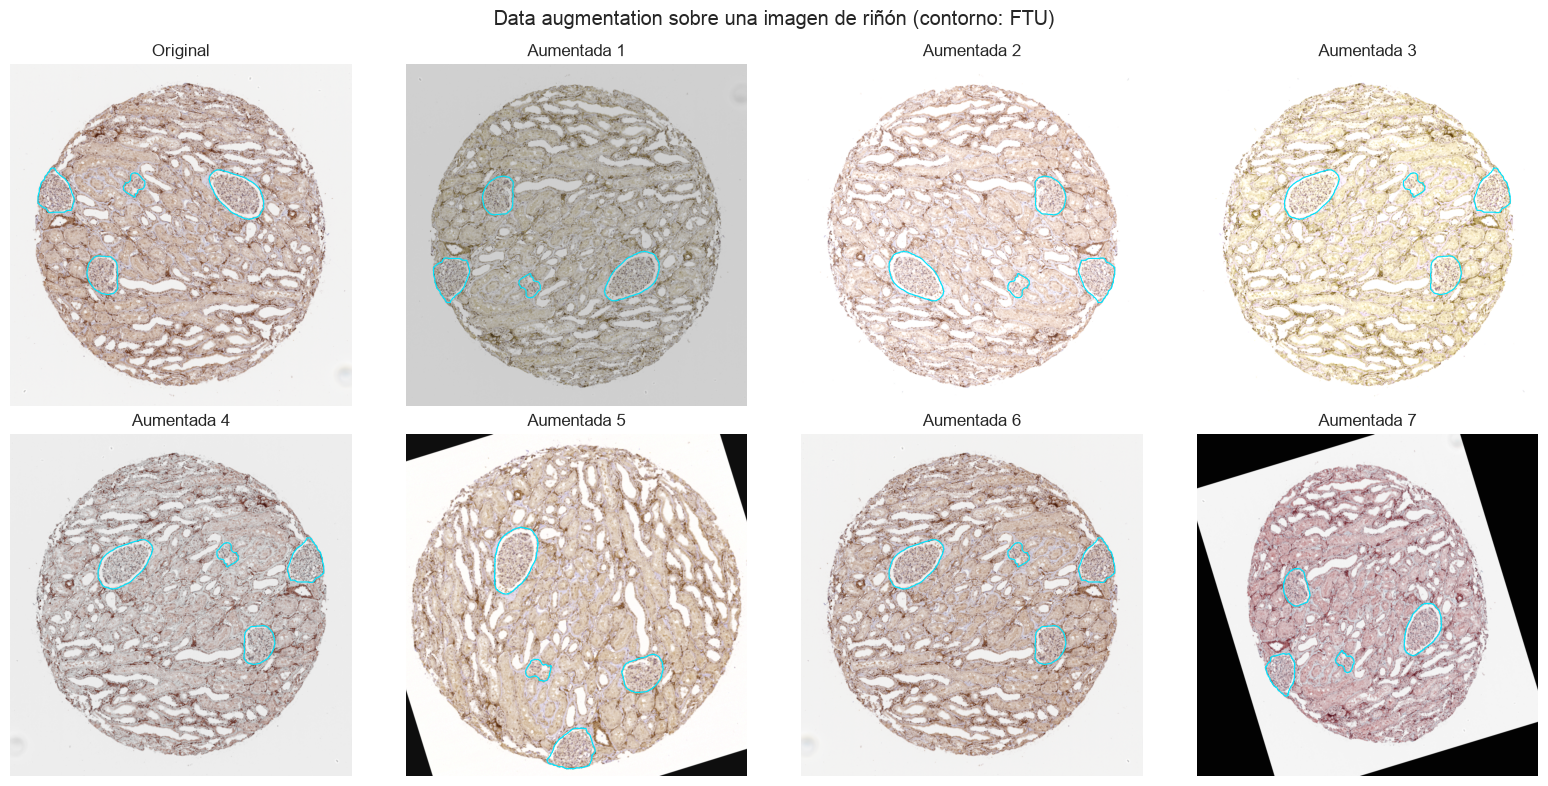

In [8]:
if HAY_IMAGENES:
    ejemplo = train[train["organ"] == "kidney"].iloc[0]
    img = cv2.cvtColor(cv2.imread(os.path.join(CACHE_DIR, f"{ejemplo['id']}.png")), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(CACHE_DIR, f"{ejemplo['id']}_mask.png"), cv2.IMREAD_GRAYSCALE)

    # Mismas transformaciones de entrenamiento, sin normalizar, para poder verlas
    aug_visual = A.Compose(pp.transformaciones("train").transforms[:-2])

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for k, ax in enumerate(axes.flat):
        out = {"image": img, "mask": mask} if k == 0 else aug_visual(image=img, mask=mask)
        ax.imshow(out["image"])
        ax.contour(out["mask"], levels=[0.5], colors="#00e5ff", linewidths=0.8)
        ax.set_title("Original" if k == 0 else f"Aumentada {k}")
        ax.axis("off")
    fig.suptitle("Data augmentation sobre una imagen de riñón (contorno: FTU)")
    plt.tight_layout()
    plt.show()

### 2.4 División en entrenamiento, validación y prueba

Se usa una división **70 / 15 / 15 estratificada por órgano**. El dataset es pequeño (351 imágenes) y desbalanceado: hay 99 de riñón pero solo 48 de pulmón. Sin estratificar, un órgano podría quedar casi sin imágenes en validación o prueba, y las métricas por órgano no serían confiables.

- **Entrenamiento:** para ajustar los pesos de los modelos.
- **Validación:** para elegir hiperparámetros y el mejor checkpoint (early stopping).
- **Prueba:** solo se usa al final para comparar los modelos, así la comparación no está sesgada.

No se usa el test de la competencia porque sus etiquetas están ocultas.

La división se guarda en `data/splits.csv` y se sube al repositorio, para que la Persona 2 y la Persona 3 usen exactamente las mismas imágenes en cada conjunto.

In [9]:
RUTA_SPLITS = os.path.join(DATA_DIR, "splits.csv")

if os.path.exists(RUTA_SPLITS):
    splits = pd.read_csv(RUTA_SPLITS)
else:
    splits = pp.crear_splits(train)
    splits.to_csv(RUTA_SPLITS, index=False)

tabla = pd.crosstab(splits["organ"], splits["split"])[["train", "val", "test"]]
tabla.loc["Total"] = tabla.sum()
tabla

split,train,val,test
organ,,,
kidney,69,15,15
largeintestine,40,9,9
lung,34,7,7
prostate,65,14,14
spleen,37,8,8
Total,245,53,53


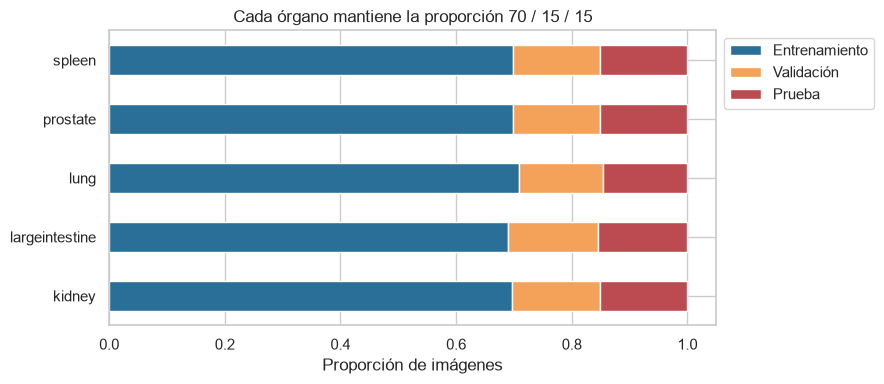

In [10]:
orden = ["train", "val", "test"]
colores = {"train": "#2a6f97", "val": "#f4a259", "test": "#bc4b51"}

proporciones = pd.crosstab(splits["organ"], splits["split"], normalize="index")[orden]
ax = proporciones.plot(kind="barh", stacked=True, figsize=(9, 4), color=[colores[s] for s in orden])
ax.set_xlabel("Proporción de imágenes")
ax.set_ylabel("")
ax.set_title("Cada órgano mantiene la proporción 70 / 15 / 15")
ax.legend(["Entrenamiento", "Validación", "Prueba"], bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### 2.5 Dataset y DataLoaders

`HubmapDataset` lee cada imagen y su máscara de la caché, aplica las transformaciones del conjunto y devuelve un diccionario:

| Clave | Contenido |
| --- | --- |
| `image` | Tensor `float32` de forma `(3, 768, 768)`, normalizado |
| `mask` | Tensor `float32` de forma `(1, 768, 768)`, con valores 0 y 1 |
| `organ` | Nombre del órgano (para calcular métricas por órgano) |
| `id` | Id de la imagen en `train.csv` |

`crear_dataloaders` arma un `DataLoader` por conjunto. Solo el de entrenamiento baraja los datos y aplica augmentation.

In [11]:
BATCH_SIZE = 8

if HAY_IMAGENES:
    loaders = pp.crear_dataloaders(splits, CACHE_DIR, size=pp.IMG_SIZE, batch_size=BATCH_SIZE)
    for nombre, loader in loaders.items():
        print(f"{nombre:5s}: {len(loader.dataset):3d} imágenes, {len(loader):2d} batches")

    batch = next(iter(loaders["train"]))
    print()
    print("image:", tuple(batch["image"].shape), batch["image"].dtype)
    print("mask: ", tuple(batch["mask"].shape), batch["mask"].unique().tolist())
    print("organ:", batch["organ"])

train: 245 imágenes, 30 batches
val  :  53 imágenes,  7 batches
test :  53 imágenes,  7 batches

image: (8, 3, 768, 768) torch.float32
mask:  (8, 1, 768, 768) [0.0, 1.0]
organ: ['prostate', 'spleen', 'largeintestine', 'spleen', 'prostate', 'prostate', 'spleen', 'largeintestine']


### 2.6 Verificación visual del pipeline

Una imagen de cada órgano, ya redimensionada, con su máscara superpuesta. Si la decodificación del RLE estuviera mal, el contorno no coincidiría con las estructuras del tejido.

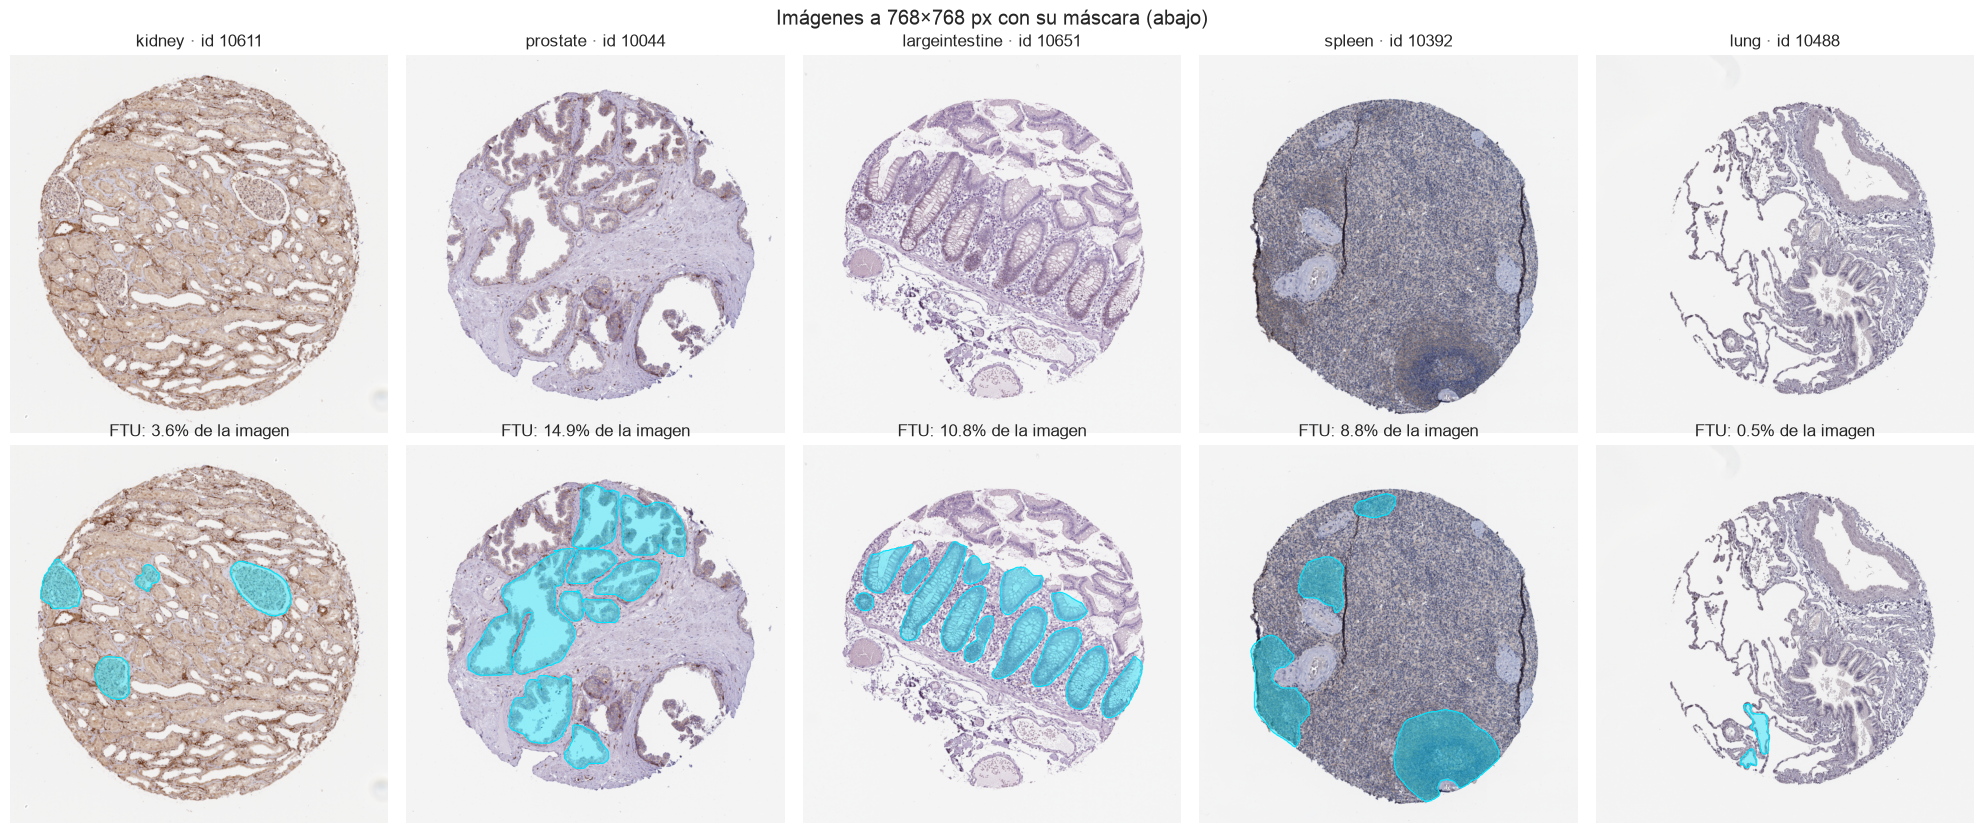

In [12]:
if HAY_IMAGENES:
    from matplotlib.colors import ListedColormap

    # Cian: contrasta con los tonos rosa y morado de la tinción
    cian = ListedColormap(["#00e5ff"])
    muestra = train.groupby("organ").head(1).set_index("organ").loc[pp.ORGANOS]

    fig, axes = plt.subplots(2, 5, figsize=(20, 8.5))
    for j, (organ, fila) in enumerate(muestra.iterrows()):
        img = cv2.cvtColor(cv2.imread(os.path.join(CACHE_DIR, f"{fila['id']}.png")), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(CACHE_DIR, f"{fila['id']}_mask.png"), cv2.IMREAD_GRAYSCALE)

        axes[0, j].imshow(img)
        axes[0, j].set_title(f"{organ} · id {fila['id']}")
        axes[1, j].imshow(img)
        axes[1, j].imshow(np.ma.masked_where(mask == 0, mask), cmap=cian, alpha=0.4, vmin=0, vmax=1)
        axes[1, j].contour(mask, levels=[0.5], colors="#00e5ff", linewidths=0.8)
        axes[1, j].set_title(f"FTU: {mask.mean():.1%} de la imagen")
        for ax in axes[:, j]:
            ax.axis("off")
    fig.suptitle(f"Imágenes a {pp.IMG_SIZE}×{pp.IMG_SIZE} px con su máscara (abajo)")
    plt.tight_layout()
    plt.show()

Un batch de entrenamiento tal como lo recibirá el modelo (se deshace la normalización solo para mostrarlo):

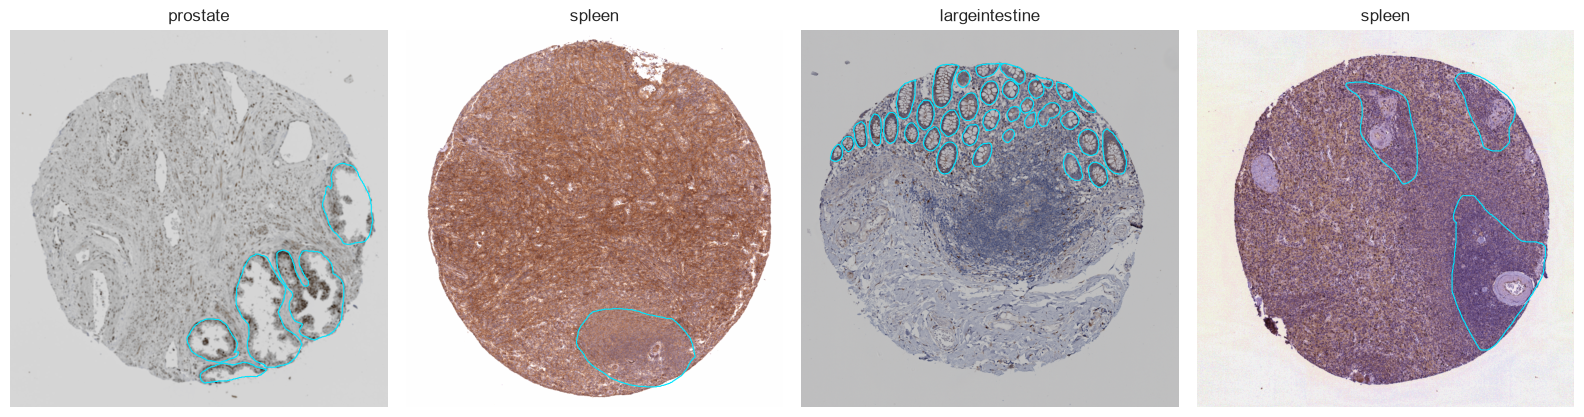

In [13]:
if HAY_IMAGENES:
    media, desv = np.array(pp.MEAN), np.array(pp.STD)
    n = min(4, BATCH_SIZE)

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4.5))
    for k in range(n):
        img = batch["image"][k].numpy().transpose(1, 2, 0) * desv + media
        axes[k].imshow(np.clip(img, 0, 1))
        axes[k].contour(batch["mask"][k, 0].numpy(), levels=[0.5], colors="#00e5ff", linewidths=0.8)
        axes[k].set_title(batch["organ"][k])
        axes[k].axis("off")
    plt.tight_layout()
    plt.show()

### 2.7 Entrega para la Persona 2

Para usar el pipeline en la sección 3 solo se necesita:

```python
loaders = pp.crear_dataloaders(splits, CACHE_DIR, size=pp.IMG_SIZE, batch_size=BATCH_SIZE)

for batch in loaders["train"]:
    imagenes, mascaras = batch["image"].to(device), batch["mask"].to(device)
    ...
```

- **Tamaño de imagen:** para probar otro tamaño (por ejemplo 512 px) en el ajuste de hiperparámetros, se pasa `size=512` a `preparar_cache` y a `crear_dataloaders`, con otro `CACHE_DIR`.
- **Dispositivo:** `device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"` funciona en compus con NVIDIA y en Mac con chip M.
- **Salida del modelo:** debe ser un solo canal `(batch, 1, H, W)` con logits; la pérdida Dice + BCE se calcula contra `batch["mask"]`.
- **SegFormer:** su salida es de 1/4 de la resolución de entrada, así que hay que interpolarla a `(768, 768)` antes de calcular la pérdida.
- **Imágenes nuevas (app):** `pp.preprocesar_para_modelo(img, pixel_size)` prepara la entrada y `pp.postprocesar(probabilidades, tamano_original)` devuelve la máscara al tamaño original.

---
## 3. Entrenamiento de los modelos

Se comparan tres arquitecturas con la misma partición, pérdida Dice + BCE y criterio de selección: el mayor Dice de validación. El conjunto de prueba queda reservado para la evaluación final de la Persona 3.

El perfil conservador para una RTX 4050 Laptop de 6 GB usa imágenes de 384 px, batch físico 1 y acumulación de 2 pasos (batch efectivo 2). Antes del entrenamiento completo, un preflight CUDA prueba cada modelo con forward, logits adaptados, pérdida, backward y un paso AdamW. Las banderas de preparación y entrenamiento empiezan en `False`: ejecutar esta sección no crea caché ni artefactos, descarga pesos, entrena o ejecuta el preflight por accidente.

### 3.1 Configuración reproducible y dispositivo

In [ ]:
from pathlib import Path

import torch

from src.models import FABRICAS_MODELOS, crear_modelo
from src.training import ejecutar_preflight_cuda, entrenar_modelo, fijar_semilla

SEMILLA = 42
RESOLUCION = 384
BATCH_ENTRENAMIENTO = 1
ACUMULACION_GRADIENTES = 2
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2
EPOCAS = 20
PACIENCIA = 5
PESOS_PREENTRENADOS = True  # ImageNet para ResNet34; Hugging Face para MIT-B0
EJECUTAR_PREPARACION = False
EJECUTAR_ENTRENAMIENTO = False

if torch.cuda.is_available():
    DISPOSITIVO = torch.device("cuda")
elif torch.backends.mps.is_available():
    DISPOSITIVO = torch.device("mps")
else:
    DISPOSITIVO = torch.device("cpu")

fijar_semilla(SEMILLA)
BATCH_EFECTIVO = BATCH_ENTRENAMIENTO * ACUMULACION_GRADIENTES
print(
    f"Dispositivo: {DISPOSITIVO} | resolución: {RESOLUCION} | "
    f"batch físico: {BATCH_ENTRENAMIENTO} | batch efectivo: {BATCH_EFECTIVO}"
)

### 3.2 Preparación explícita de caché y cargadores

Cambiar `EJECUTAR_PREPARACION` a `True` crea, si hace falta, la caché específica de 384 px y sus cargadores con batch físico 1. El último lote de entrenamiento no se descarta, por lo que se usan las 245 imágenes.

In [ ]:
CACHE_ENTRENAMIENTO = Path(DATA_DIR) / f"cache_{RESOLUCION}"
cargadores_entrenamiento = None

if EJECUTAR_PREPARACION:
    if not HAY_IMAGENES:
        raise FileNotFoundError("Faltan las imágenes de entrenamiento en data/train_images/.")
    pp.preparar_cache(train, IMG_DIR, CACHE_ENTRENAMIENTO, size=RESOLUCION)
    cargadores_entrenamiento = pp.crear_dataloaders(
        splits,
        CACHE_ENTRENAMIENTO,
        size=RESOLUCION,
        batch_size=BATCH_ENTRENAMIENTO,
        num_workers=2,
        drop_last_train=False,
    )
    print("Imágenes para ajuste:", len(cargadores_entrenamiento["train"].dataset))
    print("Imágenes para validación:", len(cargadores_entrenamiento["val"].dataset))
else:
    print("Preparación omitida. Active EJECUTAR_PREPARACION cuando quiera crear la caché de 384 px.")

### 3.3 Fábricas y protocolo común

Las fábricas de `src/models.py` configuran una salida binaria de un canal, sin sigmoide. U-Net y U-Net++ usan ResNet34. SegFormer usa MIT-B0 y entrega logits a menor resolución, que `src.training.entrenar_modelo` interpola al tamaño de la máscara mediante el adaptador común.

Para una prueba completamente offline se debe fijar `PESOS_PREENTRENADOS = False`. Para el entrenamiento real, `True` solicita pesos ImageNet en los encoders ResNet34 y `nvidia/mit-b0` en Hugging Face. La descarga solo ocurre al crear el modelo dentro del bloque de entrenamiento.

In [ ]:
CONFIGURACION_MODELOS = {
    "unet_resnet34": "U-Net / ResNet34",
    "unetplusplus_resnet34": "U-Net++ / ResNet34",
    "segformer_mit_b0": "SegFormer / MIT-B0",
}

assert set(CONFIGURACION_MODELOS) == set(FABRICAS_MODELOS)
pd.DataFrame(
    CONFIGURACION_MODELOS.items(),
    columns=["modelo", "arquitectura_encoder"],
)

### 3.4 Entrenamiento controlado y artefactos

El loop reutilizable aplica AdamW, Dice + BCE, acumulación de gradientes, validación, early stopping y guardado del mejor checkpoint. Al activar el entrenamiento, primero se prueban los tres modelos con un paso CUDA real; solo si todos caben comienza el entrenamiento. El preflight reporta picos asignados y reservados, pero no garantiza memoria futura si otros procesos empiezan a usar la GPU. Todos los artefactos se escriben bajo `data/artefactos_entrenamiento/`, una ruta excluida de Git. No se crean archivos mientras `EJECUTAR_ENTRENAMIENTO` sea `False`.

In [ ]:
COLUMNAS_HISTORIAL = [
    "modelo", "epoca", "train_loss", "train_dice", "val_loss", "val_dice",
]
COLUMNAS_EXPERIMENTOS = [
    "modelo", "arquitectura_encoder", "resolucion", "batch",
    "acumulacion_gradientes", "batch_efectivo",
    "learning_rate", "epocas_solicitadas", "epocas_ejecutadas",
    "mejor_epoca", "mejor_val_dice", "checkpoint", "estado",
]
RUTA_ARTEFACTOS = Path(DATA_DIR) / "artefactos_entrenamiento"
RUTA_HISTORIAL = RUTA_ARTEFACTOS / "historial_modelos.csv"
RUTA_EXPERIMENTOS = RUTA_ARTEFACTOS / "experimentos_modelos.csv"

historial_combinado = pd.DataFrame(columns=COLUMNAS_HISTORIAL)
experimentos = pd.DataFrame(columns=COLUMNAS_EXPERIMENTOS)

if EJECUTAR_ENTRENAMIENTO:
    if cargadores_entrenamiento is None:
        raise RuntimeError("Primero active EJECUTAR_PREPARACION y ejecute la celda de cargadores.")
    if DISPOSITIVO.type == "cuda":
        resultados_preflight = ejecutar_preflight_cuda(
            CONFIGURACION_MODELOS,
            lambda nombre: crear_modelo(nombre, pesos_preentrenados=PESOS_PREENTRENADOS),
            resolucion=RESOLUCION,
            batch_size=BATCH_ENTRENAMIENTO,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            amp=True,
        )
        print("Preflight CUDA completado para los tres modelos:")
        print(resultados_preflight.to_string(index=False))
    else:
        print("Preflight CUDA omitido: el dispositivo seleccionado no es CUDA.")
    RUTA_ARTEFACTOS.mkdir(parents=True, exist_ok=True)
    historiales = []
    registros = []

    for nombre, arquitectura in CONFIGURACION_MODELOS.items():
        modelo = crear_modelo(nombre, pesos_preentrenados=PESOS_PREENTRENADOS)
        ruta_checkpoint = RUTA_ARTEFACTOS / "checkpoints" / f"{nombre}.pt"
        resultado = entrenar_modelo(
            modelo,
            cargadores_entrenamiento["train"],
            cargadores_entrenamiento["val"],
            ruta_checkpoint=ruta_checkpoint,
            epocas=EPOCAS,
            paciencia=PACIENCIA,
            learning_rate=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
            dispositivo=DISPOSITIVO,
            amp=(DISPOSITIVO.type == "cuda"),
            seed=SEMILLA,
            acumulacion_gradientes=ACUMULACION_GRADIENTES,
        )
        historial = resultado.historial.assign(modelo=nombre)[COLUMNAS_HISTORIAL]
        historiales.append(historial)
        registros.append({
            "modelo": nombre,
            "arquitectura_encoder": arquitectura,
            "resolucion": RESOLUCION,
            "batch": BATCH_ENTRENAMIENTO,
            "acumulacion_gradientes": ACUMULACION_GRADIENTES,
            "batch_efectivo": BATCH_EFECTIVO,
            "learning_rate": LEARNING_RATE,
            "epocas_solicitadas": EPOCAS,
            "epocas_ejecutadas": len(resultado.historial),
            "mejor_epoca": resultado.mejor_epoca,
            "mejor_val_dice": resultado.mejor_val_dice,
            "checkpoint": str(resultado.ruta_checkpoint),
            "estado": "detencion_temprana" if resultado.detencion_temprana else "completado",
        })
        del modelo
        if DISPOSITIVO.type == "cuda":
            torch.cuda.empty_cache()

    historial_combinado = pd.concat(historiales, ignore_index=True)[COLUMNAS_HISTORIAL]
    experimentos = pd.DataFrame(registros, columns=COLUMNAS_EXPERIMENTOS)
    historial_combinado.to_csv(RUTA_HISTORIAL, index=False)
    experimentos.to_csv(RUTA_EXPERIMENTOS, index=False)
else:
    print("Entrenamiento omitido de forma segura. No se crearon resultados ni checkpoints.")

experimentos

### 3.5 Entrega para la Persona 3

Después de una ejecución real, la Persona 3 recibe dos CSV y tres checkpoints bajo `data/artefactos_entrenamiento/`:

- `historial_modelos.csv`: una fila por época con `modelo, epoca, train_loss, train_dice, val_loss, val_dice`.
- `experimentos_modelos.csv`: configuración, épocas solicitadas y ejecutadas, mejor época, mejor Dice de validación, checkpoint y estado por modelo.
- `checkpoints/<modelo>.pt`: mejor estado de cada modelo según validación.

Esta sección no genera métricas finales ni resultados simulados. Los pesos finales requieren ejecutar las dos banderas de forma consciente y pueden necesitar varias horas o hardware acelerado. La evaluación sobre el conjunto reservado, las métricas por órgano y la comparación final corresponden exclusivamente a la sección 4.

---
## 4. Evaluación, comparación y visualizaciones

*Pendiente (Persona 3).*

### 4.1 Evaluación en el conjunto de prueba
### 4.2 Métricas por órgano
### 4.3 Visualizaciones
### 4.4 Discusión y selección del modelo